# Exploratory Data Analysis

This notebook explores the hourly price, return, volatility, volume and cross-asset behaviour of 10 liquid cryptocurrencies from 2023 to 2025.

The analysis focuses on:

- hourly return distributions;
- annualised volatility;
- price behaviour;
- trading volume;
- cross-asset correlations;
- preliminary evidence of momentum and reversal.

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# read the cleaned data 

In [6]:
processed_data_dir = Path("data/processed")

data_path = (
    processed_data_dir
    / "crypto_10_assets_1h_clean.parquet"
)

df = pd.read_parquet(data_path)

print(df.shape)
df.head()

(263030, 11)


,open_time,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,symbol
0,2023-01-01 00:00:00+00:00,0.24580,0.24590,0.24410,0.2445,4.476440e+06,1.096436e+06,1979,2.325058e+06,5.694572e+05,ADAUSDT
1,2023-01-01 00:00:00+00:00,10.90000,10.91000,10.82000,10.8500,2.738629e+04,2.973572e+05,767,9.162430e+03,9.949916e+04,AVAXUSDT
2,2023-01-01 00:00:00+00:00,246.30000,246.70000,245.50000,245.7000,4.233967e+03,1.041745e+06,3402,1.853478e+03,4.559762e+05,BNBUSDT
3,2023-01-01 00:00:00+00:00,16541.77000,16545.70000,16508.39000,16529.6700,4.364836e+03,7.214629e+07,149854,2.179948e+03,3.603235e+07,BTCUSDT
4,2023-01-01 00:00:00+00:00,0.07024,0.07034,0.06941,0.0698,4.061193e+07,2.833808e+06,4852,1.916715e+07,1.336910e+06,DOGEUSDT


In [ ]:
# step 4: calculate the 1 -hour return

In [10]:
df = (
    df
    .sort_values(["symbol", "open_time"])
    .reset_index(drop=True)
)

df["return_1h"] = (
    df.groupby("symbol")["close"] # calculate the return based on crypto
    .pct_change()
)

In [12]:
df[
    [
        "symbol",
        "open_time",
        "close",
        "return_1h",
    ]
].head(15)

,symbol,open_time,close,return_1h
0,ADAUSDT,2023-01-01 00:00:00+00:00,0.2445,NaN
1,ADAUSDT,2023-01-01 01:00:00+00:00,0.2452,0.002863
2,ADAUSDT,2023-01-01 02:00:00+00:00,0.2456,0.001631
3,ADAUSDT,2023-01-01 03:00:00+00:00,0.2454,-0.000814
4,ADAUSDT,2023-01-01 04:00:00+00:00,0.2446,-0.003260
5,ADAUSDT,2023-01-01 05:00:00+00:00,0.2445,-0.000409
6,ADAUSDT,2023-01-01 06:00:00+00:00,0.2445,0.000000
7,ADAUSDT,2023-01-01 07:00:00+00:00,0.2452,0.002863
8,ADAUSDT,2023-01-01 08:00:00+00:00,0.2443,-0.003670
9,ADAUSDT,2023-01-01 09:00:00+00:00,0.2452,0.003684


In [ ]:
# step 5: 	total returns

In [14]:
return_summary = (
    df.groupby("symbol")["return_1h"]
    .agg(
        observations="count",
        mean_return="mean",
        volatility="std",
        minimum="min",
        maximum="max",
        skewness="skew",
    )
    .reset_index()
)

return_summary

,symbol,observations,mean_return,volatility,minimum,maximum,skewness
0,ADAUSDT,26302,0.000058,0.009618,-0.182377,0.337091,1.478646
1,AVAXUSDT,26302,0.000054,0.009890,-0.149847,0.120482,-0.163464
2,BNBUSDT,26302,0.000065,0.005929,-0.089121,0.061089,-0.451459
3,BTCUSDT,26302,0.000076,0.004992,-0.062448,0.055275,-0.079839
4,DOGEUSDT,26302,0.000070,0.009983,-0.150201,0.226093,0.549816
5,ETHUSDT,26302,0.000057,0.006607,-0.117408,0.095555,-0.273651
6,LINKUSDT,26302,0.000074,0.009380,-0.128074,0.094618,-0.235142
7,LTCUSDT,26302,0.000039,0.008354,-0.183180,0.110119,-0.476262
8,SOLUSDT,26302,0.000144,0.009786,-0.105586,0.128412,0.394577
9,XRPUSDT,26302,0.000104,0.008889,-0.148876,0.247096,1.665951


In [33]:
# we can see the SOLUSDT highest mean return, which is 0.0144%， BTC lowest volativity

In [ ]:
# step 6: calculate yearly volativity

In [16]:
hours_per_year = 24 * 365
return_summary["annualised_volatility"] = (
    return_summary["volatility"]
    * np.sqrt(hours_per_year)
)

return_summary

,symbol,observations,mean_return,volatility,minimum,maximum,skewness,annualised_volatility
0,ADAUSDT,26302,0.000058,0.009618,-0.182377,0.337091,1.478646,0.900154
1,AVAXUSDT,26302,0.000054,0.009890,-0.149847,0.120482,-0.163464,0.925652
2,BNBUSDT,26302,0.000065,0.005929,-0.089121,0.061089,-0.451459,0.554966
3,BTCUSDT,26302,0.000076,0.004992,-0.062448,0.055275,-0.079839,0.467181
4,DOGEUSDT,26302,0.000070,0.009983,-0.150201,0.226093,0.549816,0.934397
5,ETHUSDT,26302,0.000057,0.006607,-0.117408,0.095555,-0.273651,0.618388
6,LINKUSDT,26302,0.000074,0.009380,-0.128074,0.094618,-0.235142,0.877904
7,LTCUSDT,26302,0.000039,0.008354,-0.183180,0.110119,-0.476262,0.781850
8,SOLUSDT,26302,0.000144,0.009786,-0.105586,0.128412,0.394577,0.915893
9,XRPUSDT,26302,0.000104,0.008889,-0.148876,0.247096,1.665951,0.831955


In [18]:
# step 7: plot btc price

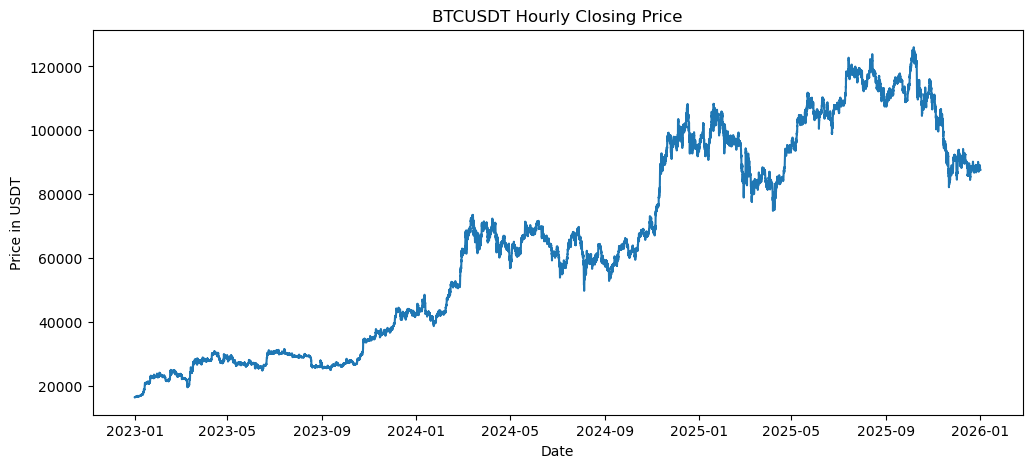

In [23]:
btc = df[
    df["symbol"] == "BTCUSDT"
].copy()

plt.figure(figsize=(12, 5))

plt.plot(
    btc["open_time"],
    btc["close"]
)

plt.title("BTCUSDT Hourly Closing Price")
plt.xlabel("Date")
plt.ylabel("Price in USDT")

plt.show()

In [ ]:
# step 8: plot all volativity

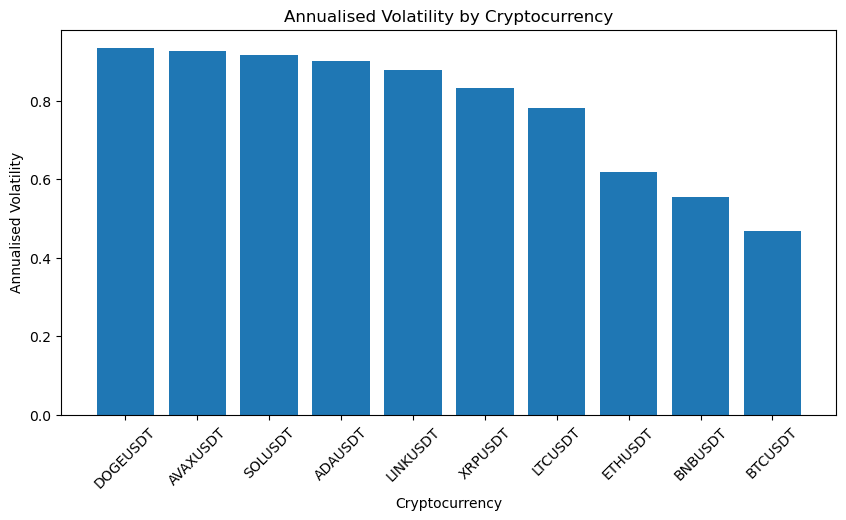

In [25]:
volatility_plot = (
    return_summary
    .sort_values(
        "annualised_volatility",
        ascending=False
    )
)

plt.figure(figsize=(10, 5))

plt.bar(
    volatility_plot["symbol"],
    volatility_plot["annualised_volatility"]
)

plt.title("Annualised Volatility by Cryptocurrency")
plt.xlabel("Cryptocurrency")
plt.ylabel("Annualised Volatility")
plt.xticks(rotation=45)

plt.show()

In [35]:
# calculate corelation matrix

In [27]:
returns_wide = df.pivot(
    index="open_time",
    columns="symbol",
    values="return_1h",
)

In [29]:
correlation_matrix = returns_wide.corr()

correlation_matrix

symbol,ADAUSDT,AVAXUSDT,BNBUSDT,BTCUSDT,DOGEUSDT,ETHUSDT,LINKUSDT,LTCUSDT,SOLUSDT,XRPUSDT
symbol,,,,,,,,,,
ADAUSDT,1.000000,0.736119,0.658940,0.691056,0.710420,0.731045,0.745973,0.691479,0.691334,0.731960
AVAXUSDT,0.736119,1.000000,0.658201,0.686722,0.685142,0.731016,0.746330,0.660057,0.731488,0.604066
BNBUSDT,0.658940,0.658201,1.000000,0.680457,0.647454,0.709681,0.664703,0.626112,0.640432,0.571625
BTCUSDT,0.691056,0.686722,0.680457,1.000000,0.688732,0.807846,0.690897,0.646985,0.710907,0.597152
DOGEUSDT,0.710420,0.685142,0.647454,0.688732,1.000000,0.718802,0.694713,0.659783,0.651244,0.616946
ETHUSDT,0.731045,0.731016,0.709681,0.807846,0.718802,1.000000,0.772909,0.681677,0.713576,0.628782
LINKUSDT,0.745973,0.746330,0.664703,0.690897,0.694713,0.772909,1.000000,0.689177,0.686137,0.621665
LTCUSDT,0.691479,0.660057,0.626112,0.646985,0.659783,0.681677,0.689177,1.000000,0.615100,0.631583
SOLUSDT,0.691334,0.731488,0.640432,0.710907,0.651244,0.713576,0.686137,0.615100,1.000000,0.576029


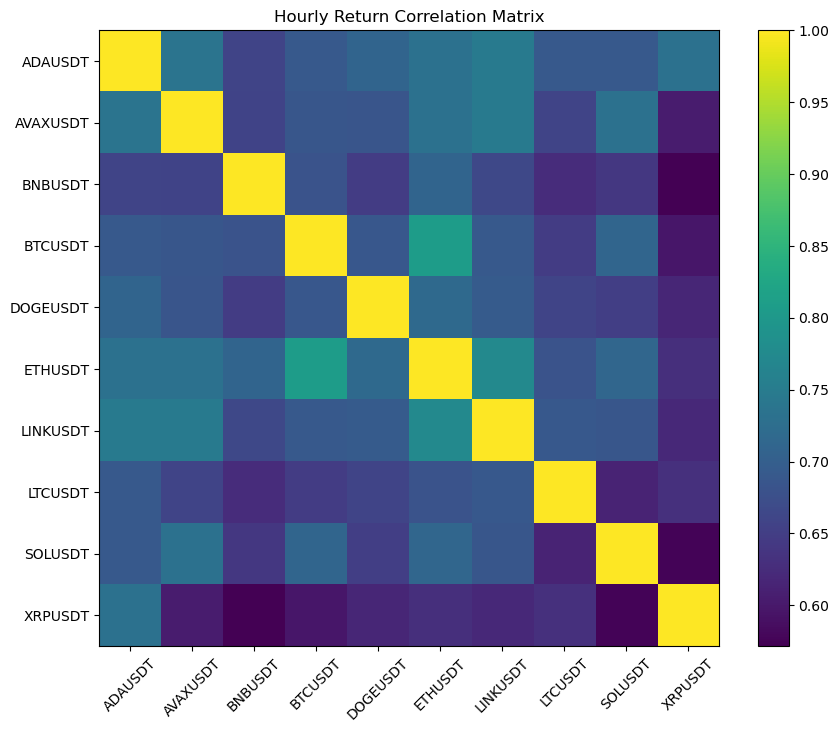

In [31]:
plt.figure(figsize=(10, 8))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index,
)

plt.title("Hourly Return Correlation Matrix")

plt.show()

## Exploratory Analysis Summary

Hourly cryptocurrency returns exhibit substantial variation in volatility and tail behaviour across assets. BTCUSDT has the lowest annualised volatility in the selected universe, while DOGEUSDT, AVAXUSDT and SOLUSDT are among the most volatile assets.

Large positive and negative hourly returns indicate that cryptocurrency return distributions contain extreme observations and are unlikely to be well described by a normal distribution.

Hourly returns are positively correlated across all ten assets, with particularly strong co-movement between BTCUSDT and ETHUSDT. This suggests the presence of a common cryptocurrency market factor. At the same time, correlations remain below one, leaving meaningful cross-sectional variation that may support relative-value momentum or reversal strategies.